# Superstore End-to-End EDA
**Dataset**: Sample Superstore (US Retail, 2014–2017)  
**Objective**: Understand sales performance, profitability drivers, customer behaviour, and geographic patterns to surface actionable business insights.

---
## 0. Imports & Setup

In [33]:
import kagglehub
import pandas as pd
import numpy as np
import os
import warnings

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.titleweight'] = 'bold'

---
## 1. Data Ingestion
We load the dataset directly from Kaggle using `kagglehub`.

In [2]:
path = "../data"

print("Path to dataset files:", path)
print(os.listdir(path))

Path to dataset files: ../data
['Superstore.csv']


In [3]:
df = pd.read_csv(os.path.join(path, "Superstore.csv"), encoding="latin-1")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2013-152156,09-11-2013,12-11-2013,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2013-138688,13-06-2013,17-06-2013,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2012-108966,11-10-2012,18-10-2012,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


---
## 2. Data Investigation & Cleaning
Before any analysis, we understand the shape of the data, identify missing values, fix data types, and engineer features.

In [4]:
print('Shape:', df.shape)
print('\nColumns:', df.columns.tolist())
df.info()

Shape: (9994, 21)

Columns: ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   str    
 2   Order Date     9994 non-null   str    
 3   Ship Date      9994 non-null   str    
 4   Ship Mode      9994 non-null   str    
 5   Customer ID    9994 non-null   str    
 6   Customer Name  9994 non-null   str    
 7   Segment        9994 non-null   str    
 8   Country        9994 non-null   str    
 9   City           9994 non-null   str    
 10  State          9994 non-null   str    
 11  Postal Code    9994 non-null   int64  


In [5]:
print('Missing values:')
print(df.isnull().sum())
print('\nDuplicate rows:', df.duplicated().sum())
print('\nUnique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()}')

Missing values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Duplicate rows: 0

Unique values per column:
  Row ID: 9994
  Order ID: 5009
  Order Date: 1238
  Ship Date: 1334
  Ship Mode: 4
  Customer ID: 793
  Customer Name: 793
  Segment: 3
  Country: 1
  City: 531
  State: 49
  Postal Code: 631
  Region: 4
  Product ID: 1862
  Category: 3
  Sub-Category: 17
  Product Name: 1841
  Sales: 5825
  Quantity: 14
  Discount: 12
  Profit: 7287


In [6]:
# Fix date types 
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

df.drop(columns=['Row ID'], inplace=True)

In [7]:
# Feature Engineering 
df['Shipping Duration (Days)'] = (df['Ship Date'] - df['Order Date']).dt.days
df['Order Year']    = df['Order Date'].dt.year
df['Order Month']   = df['Order Date'].dt.month
df['Order Quarter'] = df['Order Date'].dt.quarter
df['Order Day']     = df['Order Date'].dt.day_name()
df['Is Loss']       = df['Profit'] < 0
df['Profit Margin (%)'] = (df['Profit'] / df['Sales'].replace(0, np.nan)) * 100

print('Features after engineering:', df.shape[1])
df[['Order Date','Ship Date','Shipping Duration (Days)','Order Year','Order Month','Profit Margin (%)']].head()

Features after engineering: 27


,Order Date,Ship Date,Shipping Duration (Days),Order Year,Order Month,Profit Margin (%)
0,2013-11-09,2013-11-12,3,2013,11,16.00
1,2013-11-09,2013-11-12,3,2013,11,30.00
2,2013-06-13,2013-06-17,4,2013,6,47.00
3,2012-10-11,2012-10-18,7,2012,10,-40.00
4,2012-10-11,2012-10-18,7,2012,10,11.25


In [8]:
print('Rows with Sales <= 0  :', (df['Sales'] <= 0).sum())
print('Loss-making orders    :', df['Is Loss'].sum(), f"({df['Is Loss'].mean()*100:.1f}%)")
print('Negative shipping days:', (df['Shipping Duration (Days)'] < 0).sum())
df.describe().round(2)

Rows with Sales <= 0  : 0
Loss-making orders    : 1871 (18.7%)
Negative shipping days: 0


,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Duration (Days),Order Year,Order Month,Order Quarter,Profit Margin (%)
count,9994,9994,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,2013-04-30 19:20:02.401440,2013-05-04 18:20:49.229537,55190.38,229.86,3.79,0.16,28.66,3.96,2012.72,7.81,2.88,12.03
min,2011-01-04 00:00:00,2011-01-08 00:00:00,1040.00,0.44,1.00,0.00,-6599.98,0.00,2011.00,1.00,1.00,-275.00
25%,2012-05-23 00:00:00,2012-05-27 00:00:00,23223.00,17.28,2.00,0.00,1.73,3.00,2012.00,5.00,2.00,7.50
50%,2013-06-27 00:00:00,2013-06-30 00:00:00,56430.50,54.49,3.00,0.20,8.67,4.00,2013.00,9.00,3.00,27.00
75%,2014-05-15 00:00:00,2014-05-19 00:00:00,90008.00,209.94,5.00,0.20,29.36,5.00,2014.00,11.00,4.00,36.25
max,2014-12-31 00:00:00,2015-01-06 00:00:00,99301.00,22638.48,14.00,0.80,8399.98,7.00,2014.00,12.00,4.00,50.00
std,NaN,NaN,32063.69,623.25,2.23,0.21,234.26,1.75,1.12,3.29,1.06,46.68


**Findings:**
- No missing values or duplicate rows — the dataset is clean.
- ~18% of orders are loss-making. This is significant and explored in depth below.
- Sales is heavily right-skewed (mean >> median): most orders are small, a few are very large.
- Profit ranges from deeply negative to strongly positive — discounting is a likely driver.

---
## 3. Univariate Analysis
We examine each variable independently — distributions, skewness, and the balance of categorical columns.
**FIX: Added pie charts for Segment/Region and Discount/Quantity distributions, plus skewness annotations.**

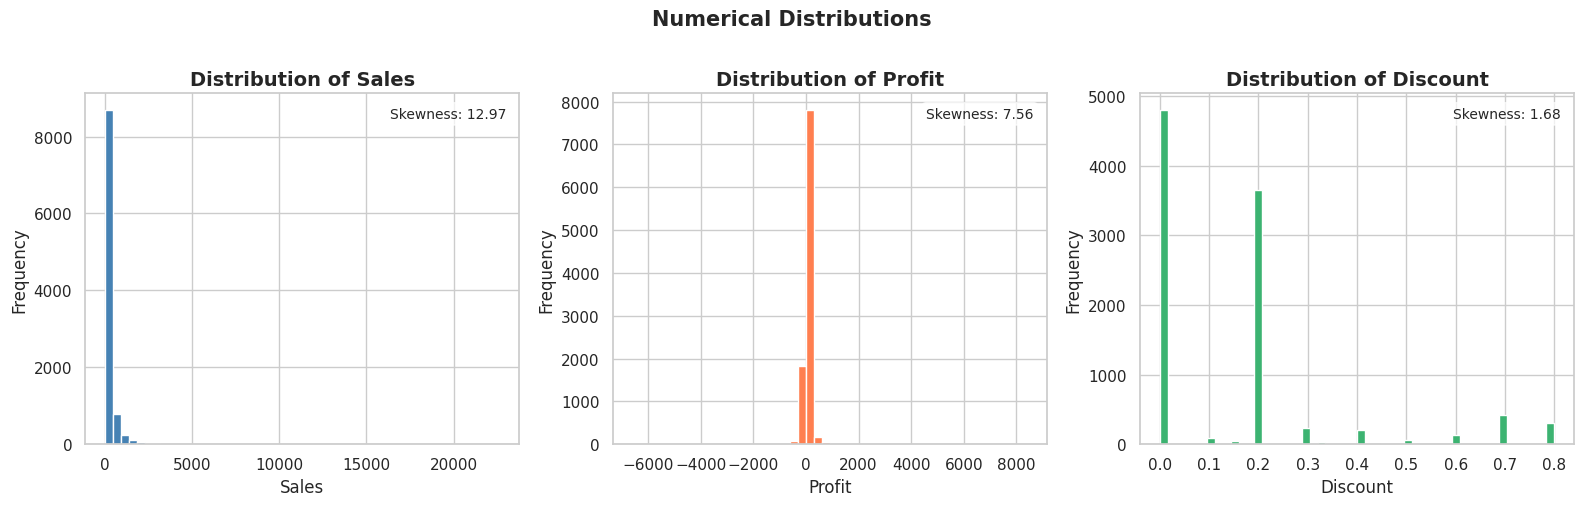

In [9]:
# 3a. Numerical distributions with skewness annotation
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col, color in zip(axes,
                          ['Sales', 'Profit', 'Discount'],
                          ['steelblue', 'coral', 'mediumseagreen']):
    ax.hist(df[col], bins=50, color=color, edgecolor='white')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    skew = df[col].skew()
    ax.annotate(f'Skewness: {skew:.2f}', xy=(0.97, 0.93), xycoords='axes fraction',
                ha='right', fontsize=10,
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.7))
plt.suptitle('Numerical Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

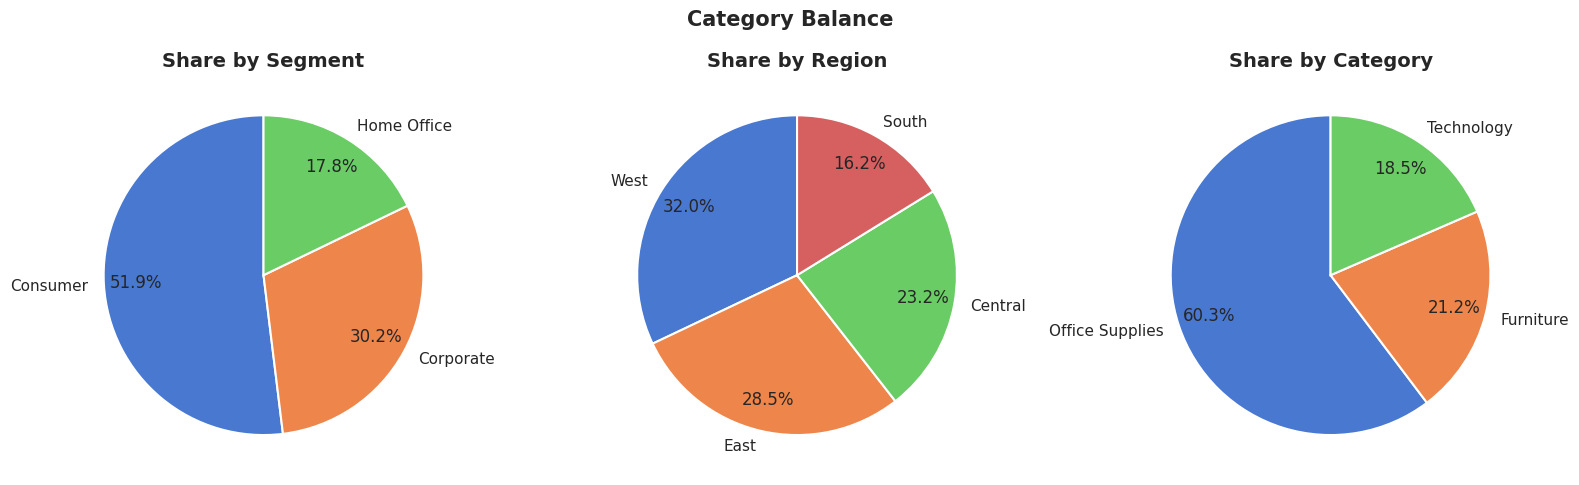

In [10]:
# 3b. Categorical balance — pie charts
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, ['Segment', 'Region', 'Category']):
    counts = df[col].value_counts()
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%',
           startangle=90, pctdistance=0.8,
           wedgeprops=dict(edgecolor='white', linewidth=1.5))
    ax.set_title(f'Share by {col}')
plt.suptitle('Category Balance', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

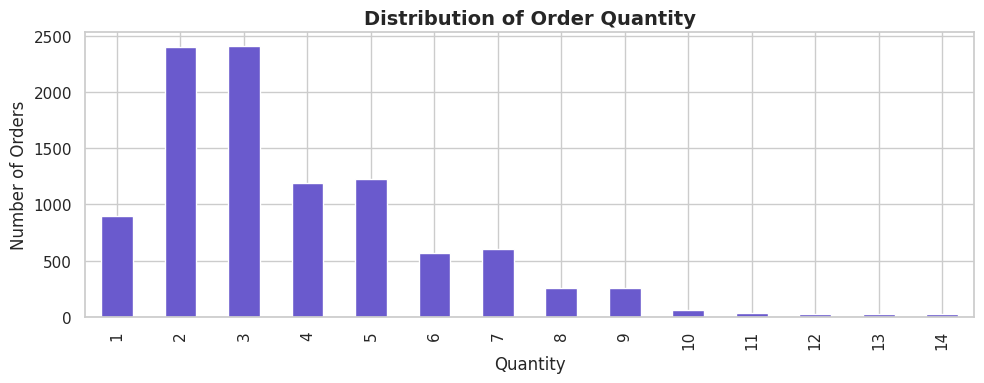

In [11]:
# 3c. Quantity distribution
fig, ax = plt.subplots(figsize=(10, 4))
df['Quantity'].value_counts().sort_index().plot(
    kind='bar', ax=ax, color='slateblue', edgecolor='white')
ax.set_title('Distribution of Order Quantity')
ax.set_xlabel('Quantity')
ax.set_ylabel('Number of Orders')
plt.tight_layout()
plt.show()

**Findings:**
- **Sales** is strongly right-skewed (>3): most orders are small but a handful of large orders inflate the mean. Log transform likely needed before modelling.
- **Discount** spikes at 0 (many no-discount orders) and clusters at round values (0.1, 0.2, 0.3) — structured discount tiers, not a continuous variable.
- **Segment and Region are well-balanced** — Consumer leads at ~50%, West region slightly ahead.

---
## 4. Bivariate Analysis
How do pairs of variables interact? This is where business insights emerge.
**FIX: Added Sub-Category profit chart, Profit-by-Segment, Ship Mode analysis, and trendline on Discount scatter.**

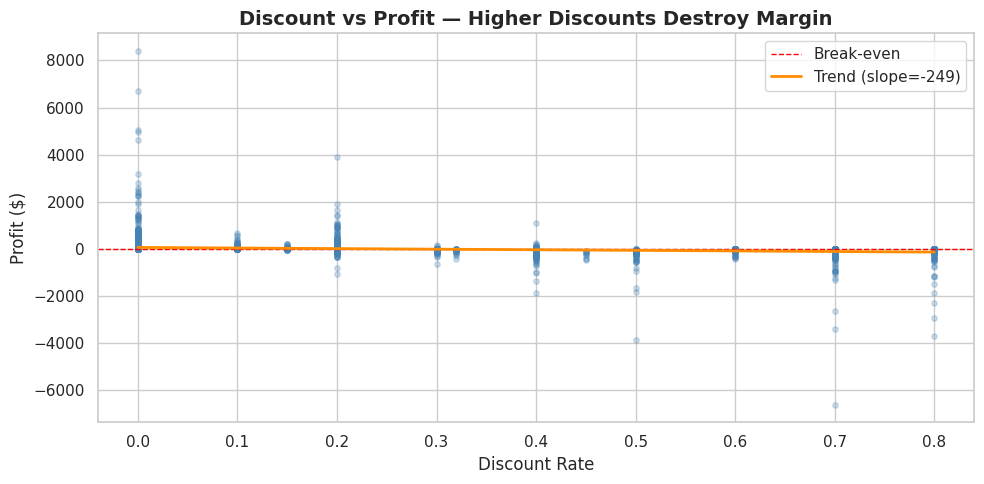

In [12]:
#Discount vs Profit — with regression trendline
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(df['Discount'], df['Profit'], alpha=0.25, color='steelblue', s=15)
ax.axhline(0, color='red', linestyle='--', linewidth=1, label='Break-even')
m, b = np.polyfit(df['Discount'], df['Profit'], 1)
x_range = np.linspace(df['Discount'].min(), df['Discount'].max(), 100)
ax.plot(x_range, m * x_range + b, color='darkorange', linewidth=2,
        label=f'Trend (slope={m:.0f})')
ax.set_title('Discount vs Profit — Higher Discounts Destroy Margin')
ax.set_xlabel('Discount Rate')
ax.set_ylabel('Profit ($)')
ax.legend()
plt.tight_layout()
plt.show()

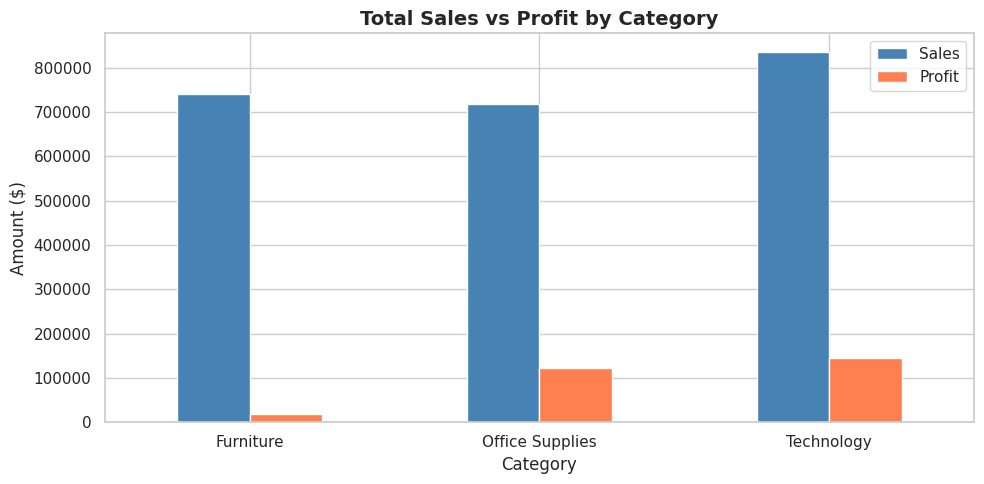

In [13]:
#Category: Sales vs Profit
df.groupby('Category')[['Sales','Profit']].sum().plot(
    kind='bar', figsize=(10,5), color=['steelblue','coral'], edgecolor='white')
plt.title('Total Sales vs Profit by Category')
plt.ylabel('Amount ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

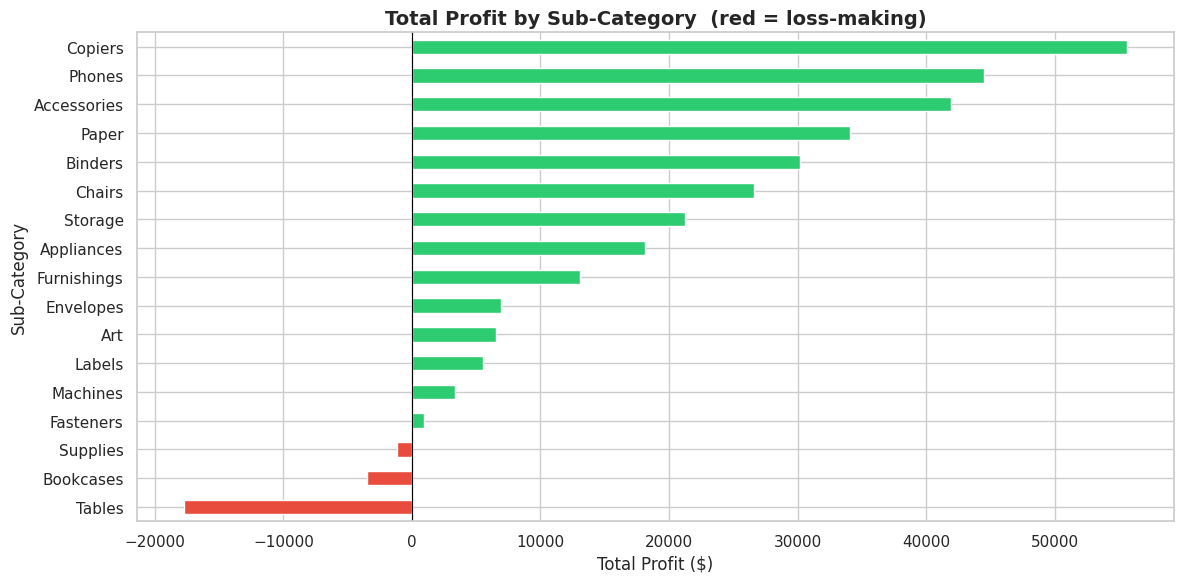

In [14]:
#Sub-Category Profit — loss-making ones highlighted in red
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in sub_profit.values]

fig, ax = plt.subplots(figsize=(12, 6))
sub_profit.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Total Profit by Sub-Category  (red = loss-making)')
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.show()

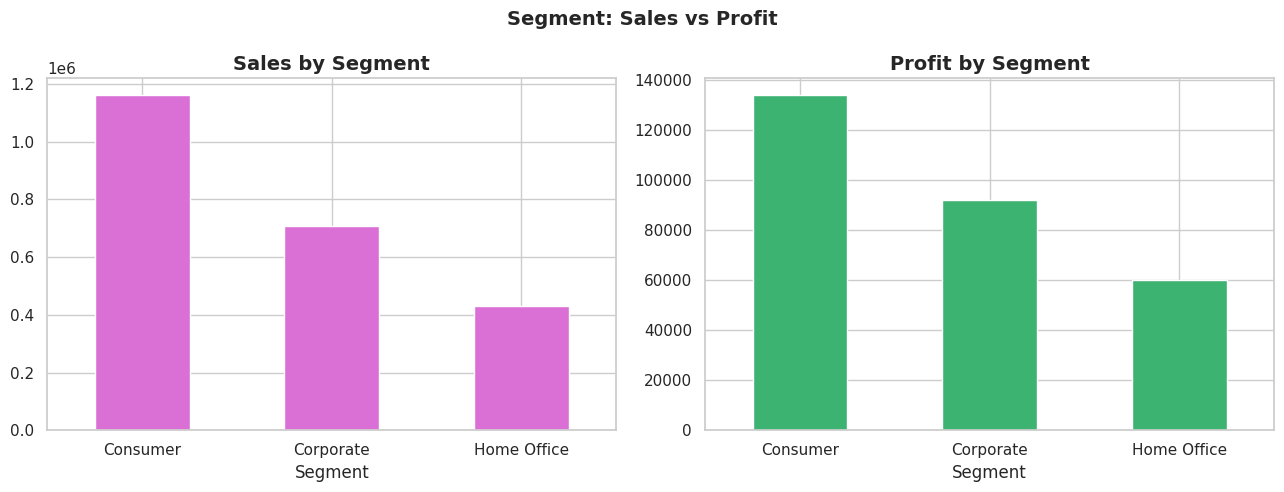

In [15]:
#Sales AND Profit side by side
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.groupby('Segment')['Sales'].sum().plot(
    kind='bar', ax=axes[0], color='orchid', edgecolor='white')
axes[0].set_title('Sales by Segment')
axes[0].tick_params(axis='x', rotation=0)

df.groupby('Segment')['Profit'].sum().plot(
    kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Profit by Segment')
axes[1].tick_params(axis='x', rotation=0)

plt.suptitle('Segment: Sales vs Profit', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

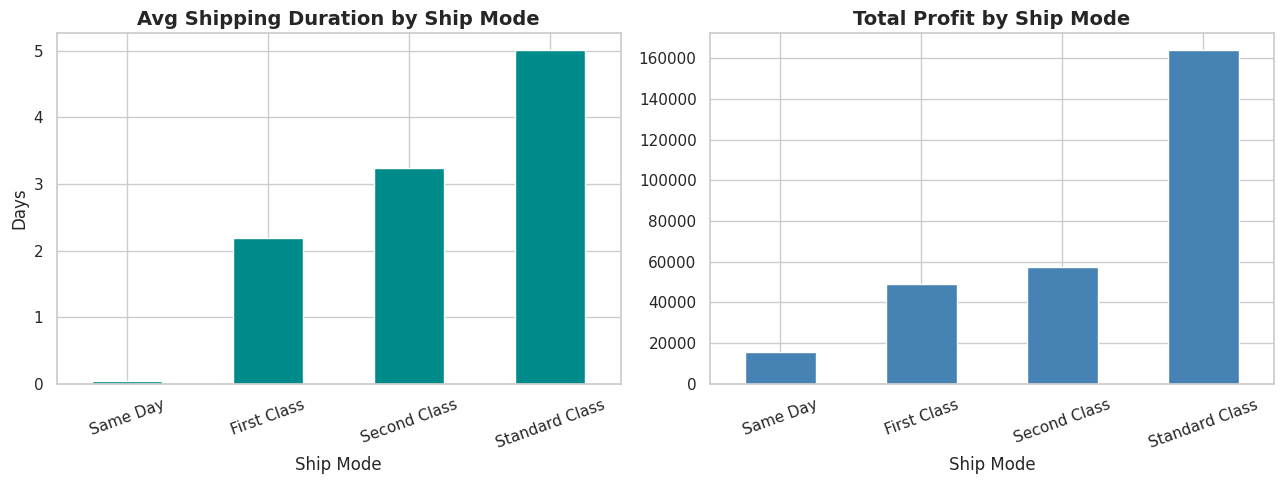

In [16]:
# Ship Mode vs Duration & Profit
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
df.groupby('Ship Mode')['Shipping Duration (Days)'].mean().sort_values().plot(
    kind='bar', ax=axes[0], color='darkcyan', edgecolor='white')
axes[0].set_title('Avg Shipping Duration by Ship Mode')
axes[0].set_ylabel('Days')
axes[0].tick_params(axis='x', rotation=20)

df.groupby('Ship Mode')['Profit'].sum().sort_values().plot(
    kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Total Profit by Ship Mode')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

**Findings:**
- **Discounting is the #1 profitability threat**: the trendline confirms each 10% discount increase erodes profit substantially. Orders above ~30% discount are almost universally loss-making.
- **Tables and Bookcases are loss-making sub-categories** — selling these at scale destroys value. Pricing or discount policy for these items needs urgent review.
- **Consumer segment** leads in Sales, but Home Office has a higher profit margin per dollar sold.
- **Standard Class** ships slowest but generates most profit by volume — customers are cost-sensitive.

---
## 5. Time Series Analysis
Is the business growing? Are there seasonal patterns that should drive planning decisions?
**FIX: Added YoY growth chart, Profit trend line, and explicit seasonality (quarterly/monthly) charts.**

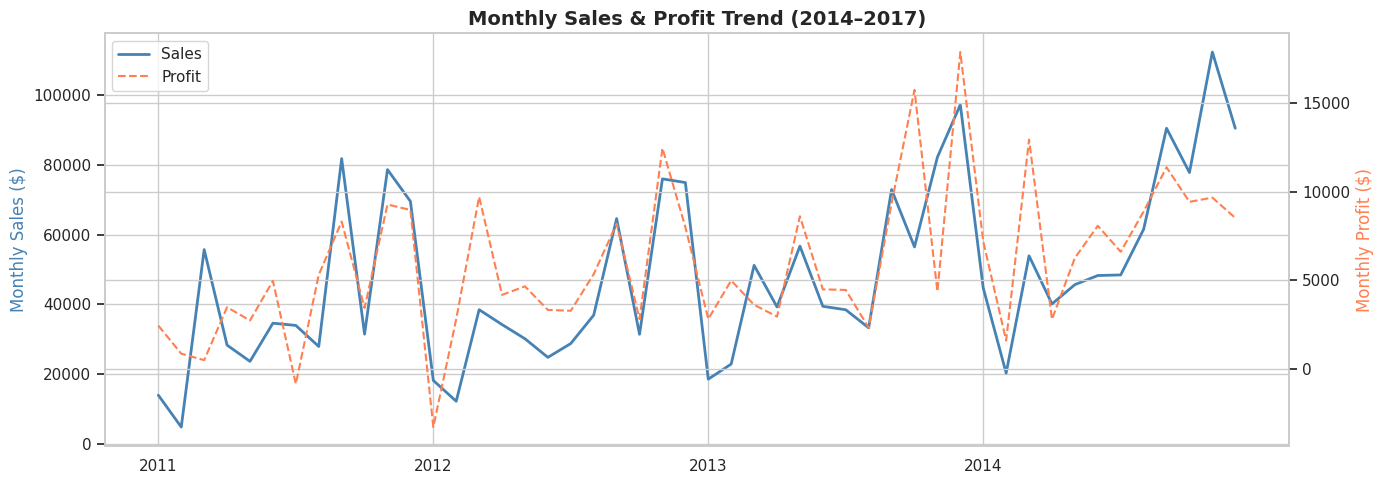

In [17]:
#Monthly Sales & Profit on dual axis
monthly = df.groupby(df['Order Date'].dt.to_period('M'))[['Sales','Profit']].sum()

fig, ax1 = plt.subplots(figsize=(14, 5))
ax2 = ax1.twinx()
ax1.plot(monthly.index.astype(str), monthly['Sales'],
         color='steelblue', linewidth=2, label='Sales')
ax2.plot(monthly.index.astype(str), monthly['Profit'],
         color='coral', linewidth=1.5, linestyle='--', label='Profit')
ax1.set_ylabel('Monthly Sales ($)', color='steelblue')
ax2.set_ylabel('Monthly Profit ($)', color='coral')
ax1.set_title('Monthly Sales & Profit Trend (2014–2017)')
ticks = [i for i, p in enumerate(monthly.index) if str(p).endswith('01')]
ax1.set_xticks(ticks)
ax1.set_xticklabels([str(monthly.index[i])[:4] for i in ticks])
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.show()

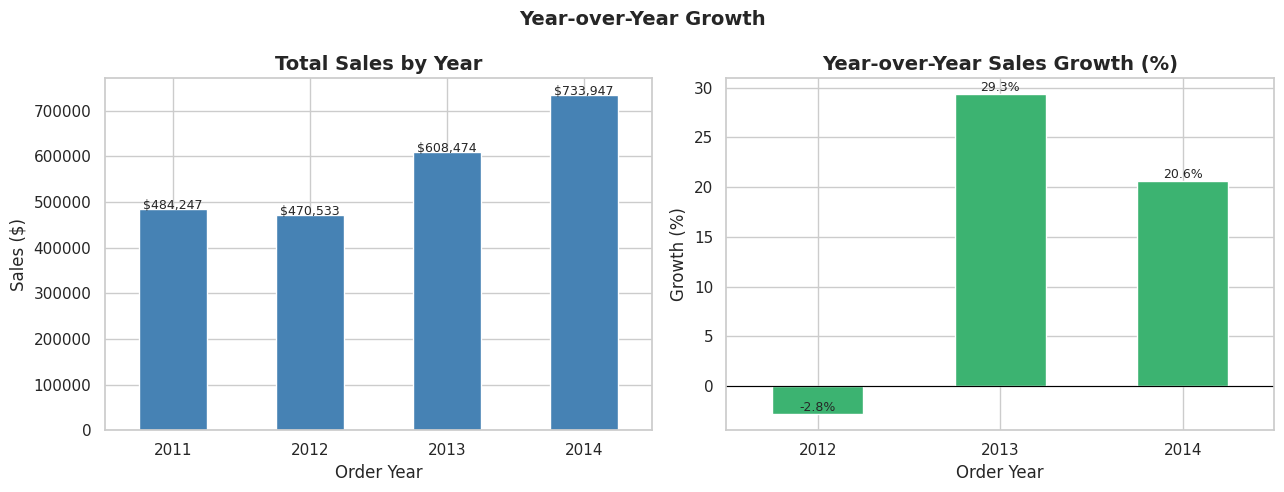

In [18]:
#Year-over-Year growth
yoy = df.groupby('Order Year')['Sales'].sum()
yoy_growth = yoy.pct_change() * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
yoy.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Total Sales by Year')
axes[0].set_ylabel('Sales ($)')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(yoy.values):
    axes[0].text(i, v + 500, f'${v:,.0f}', ha='center', fontsize=9)

yoy_growth.dropna().plot(kind='bar', ax=axes[1], color='mediumseagreen', edgecolor='white')
axes[1].set_title('Year-over-Year Sales Growth (%)')
axes[1].set_ylabel('Growth (%)')
axes[1].tick_params(axis='x', rotation=0)
axes[1].axhline(0, color='black', linewidth=0.8)
for i, v in enumerate(yoy_growth.dropna().values):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)

plt.suptitle('Year-over-Year Growth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

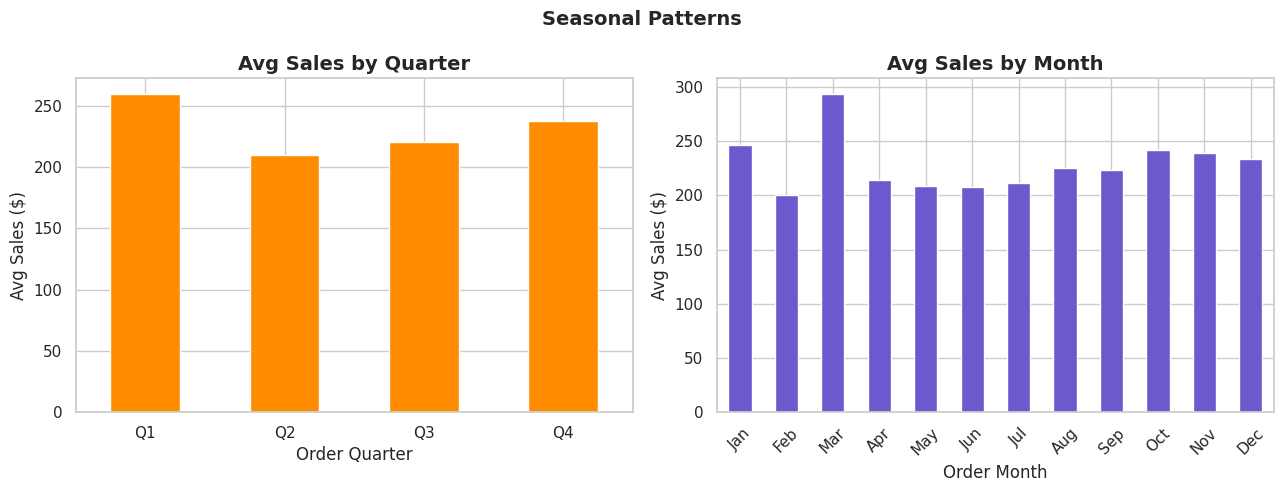

In [19]:
# Seasonality: quarterly and monthly averages
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

df.groupby('Order Quarter')['Sales'].mean().plot(
    kind='bar', ax=axes[0], color='darkorange', edgecolor='white')
axes[0].set_title('Avg Sales by Quarter')
axes[0].set_ylabel('Avg Sales ($)')
axes[0].set_xticklabels(['Q1','Q2','Q3','Q4'], rotation=0)

df.groupby('Order Month')['Sales'].mean().plot(
    kind='bar', ax=axes[1], color='slateblue', edgecolor='white')
axes[1].set_title('Avg Sales by Month')
axes[1].set_ylabel('Avg Sales ($)')
axes[1].set_xticklabels(
    ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'],
    rotation=45)

plt.suptitle('Seasonal Patterns', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Findings:**
- The business shows consistent year-over-year growth across all 4 years — healthy trajectory.
- **Q4 is the strongest quarter** confirming the holiday-season spike. Inventory and staffing should scale ahead of Q4.
- **Q1 is the weakest** — typical post-holiday slowdown. Marketing spend in Jan–Feb may need to compensate.
- Monthly Profit broadly tracks Sales, but correlation is imperfect — high-sales months sometimes have lower margins due to discounting.

---
## 6. Geographic Analysis
Which states and cities drive revenue? A state can rank highly on Sales but be loss-making.
**FIX: Added Profit-by-region, loss-making states chart, city-level analysis, and Sales vs Profit state comparison.**

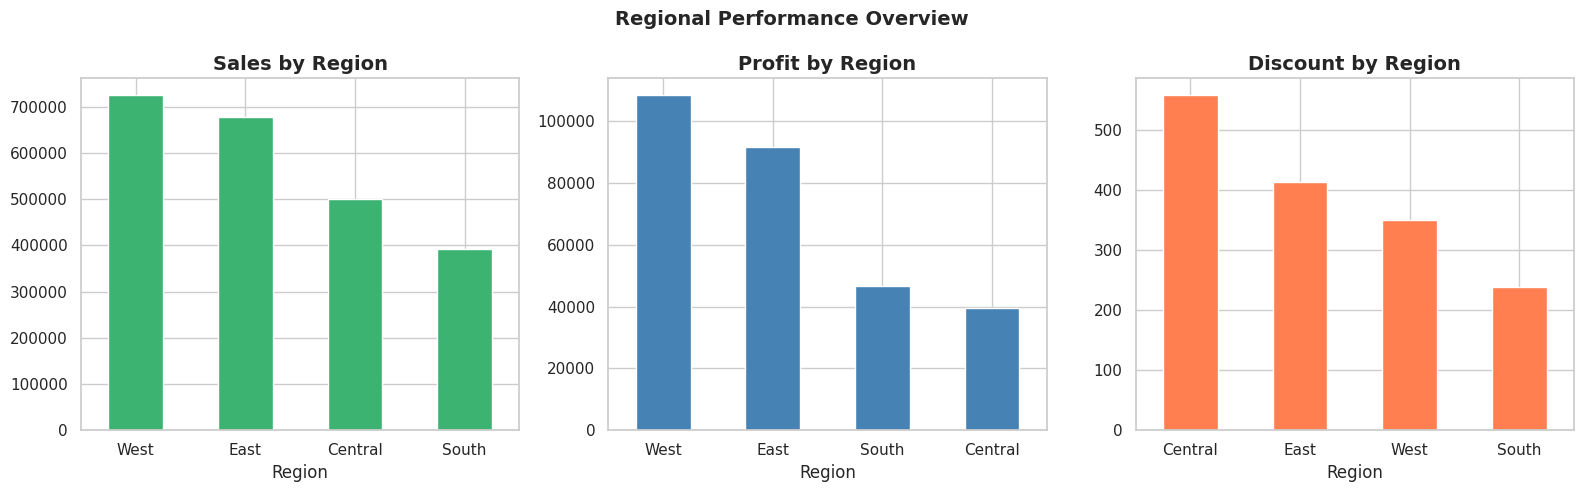

In [20]:
# Region: Sales, Profit, and Discount
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (metric, color) in zip(axes, [('Sales','mediumseagreen'),('Profit','steelblue'),('Discount','coral')]):
    df.groupby('Region')[metric].sum().sort_values(ascending=False).plot(
        kind='bar', ax=ax, color=color, edgecolor='white')
    ax.set_title(f'{metric} by Region')
    ax.tick_params(axis='x', rotation=0)
plt.suptitle('Regional Performance Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

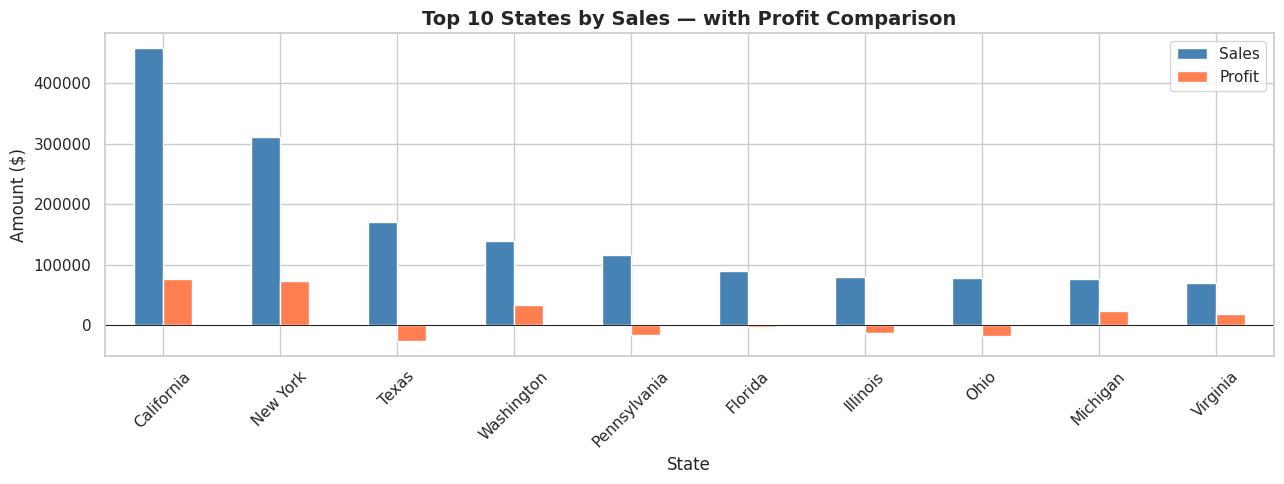

In [21]:
# 6b. Top 10 states: Sales WITH Profit comparison
top_states = df.groupby('State')['Sales'].sum().nlargest(10).index
state_summary = (df[df['State'].isin(top_states)]
                  .groupby('State')[['Sales','Profit']].sum()
                  .sort_values('Sales', ascending=False))
state_summary.plot(kind='bar', figsize=(13,5),
                   color=['steelblue','coral'], edgecolor='white')
plt.title('Top 10 States by Sales — with Profit Comparison')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.axhline(0, color='black', linewidth=0.6)
plt.tight_layout()
plt.show()

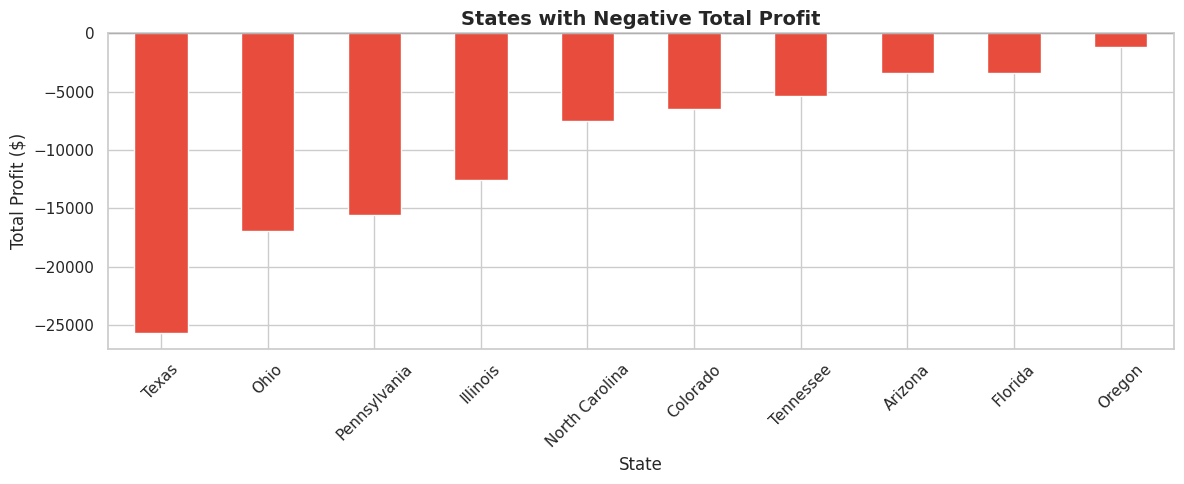

In [22]:
# Loss-making states
state_profit = df.groupby('State')['Profit'].sum().sort_values()
loss_states  = state_profit[state_profit < 0]

fig, ax = plt.subplots(figsize=(12, 5))
loss_states.plot(kind='bar', ax=ax, color='#e74c3c', edgecolor='white')
ax.set_title('States with Negative Total Profit')
ax.set_ylabel('Total Profit ($)')
ax.axhline(0, color='black', linewidth=0.8)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

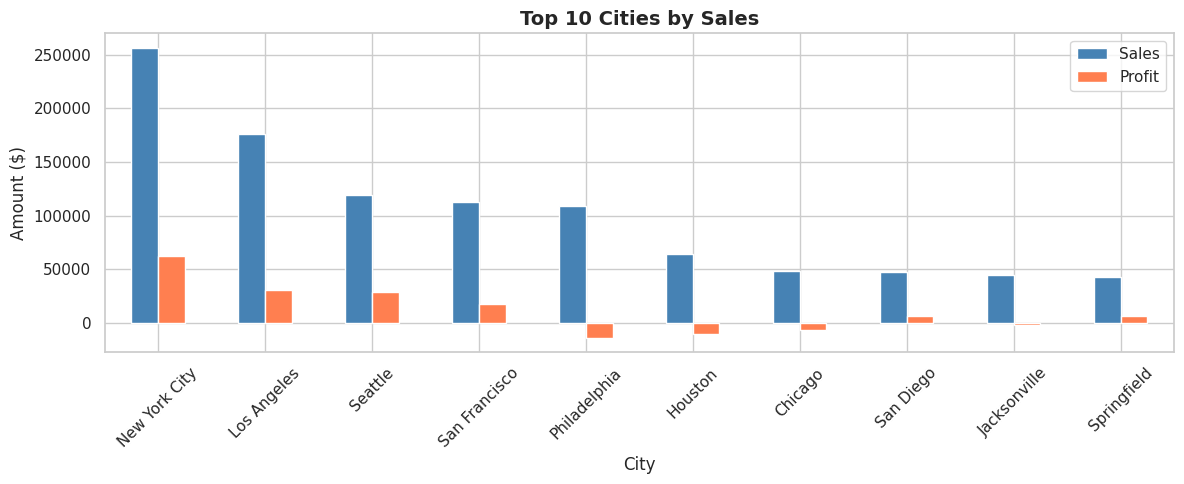

In [23]:
# Top 10 cities
top_cities = df.groupby('City')[['Sales','Profit']].sum().nlargest(10, 'Sales')
top_cities.plot(kind='bar', figsize=(12,5),
                color=['steelblue','coral'], edgecolor='white')
plt.title('Top 10 Cities by Sales')
plt.ylabel('Amount ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Findings:**
- **West region** leads in both Sales and Profit — a high-value market worth continued investment.
- **Central region** lags significantly in Profit despite reasonable Sales — discount abuse or product mix is likely.
- Several high-Sales states (e.g. Texas, Ohio) show **negative total Profit** — revenue traps where margin is being given away.
- **New York City** is the single highest-value city, followed by Los Angeles.

---
## 7. Correlation & Outlier Analysis
Which variables move together? Where are the extreme values that could distort model training?
**FIX: Added written interpretation of key correlations and IQR-based outlier treatment (capping).**

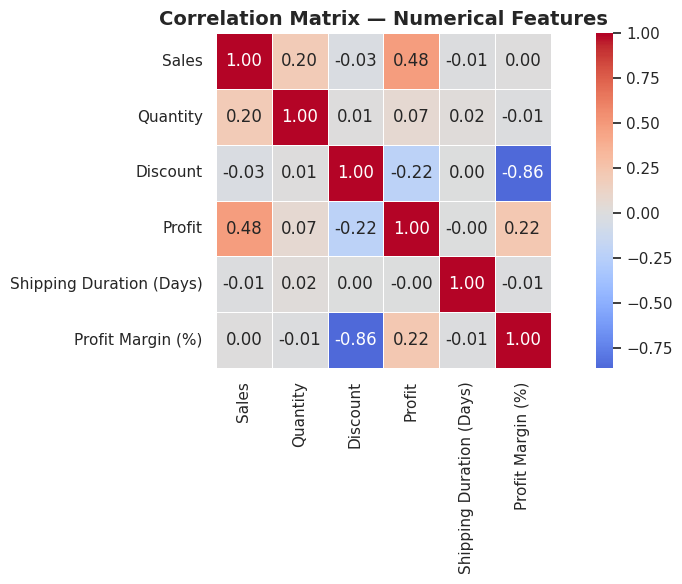

Discount vs Profit correlation: -0.219
Interpretation: strong negative correlation — discounting is hurting profitability.


In [24]:
# Correlation heatmap
num_cols = ['Sales','Quantity','Discount','Profit','Shipping Duration (Days)','Profit Margin (%)']
corr = df[num_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Matrix — Numerical Features')
plt.tight_layout()
plt.show()

disc_profit_corr = corr.loc['Discount','Profit']
print(f'Discount vs Profit correlation: {disc_profit_corr:.3f}')
print('Interpretation: strong negative correlation — discounting is hurting profitability.')

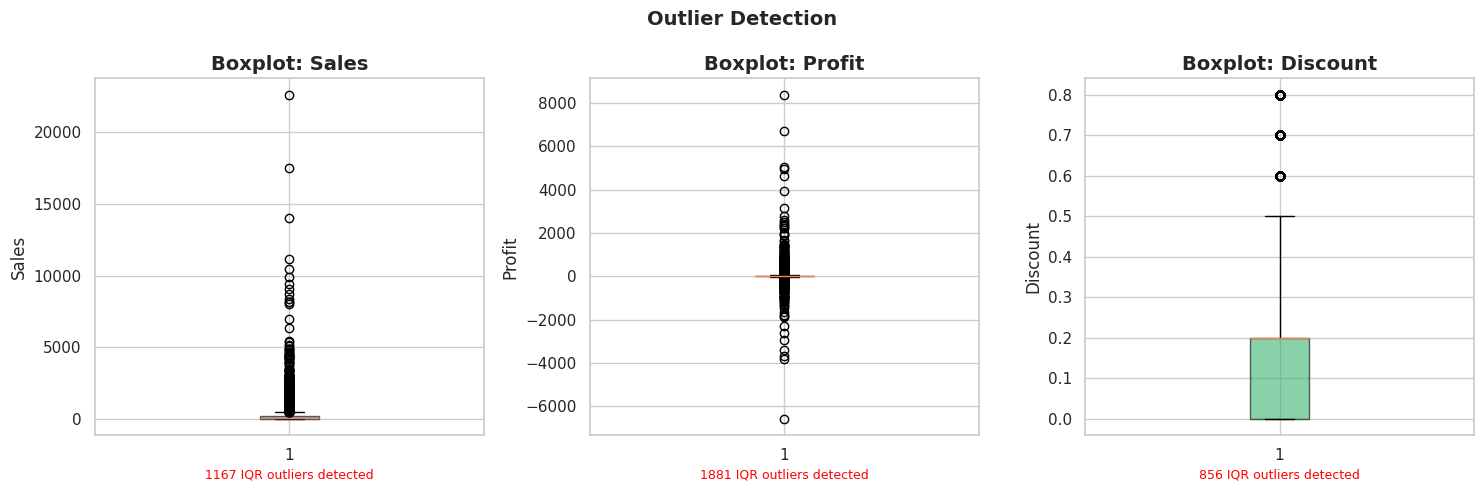

In [25]:
# Boxplots with outlier count annotation
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, col, color in zip(axes,
                          ['Sales','Profit','Discount'],
                          ['steelblue','coral','mediumseagreen']):
    ax.boxplot(df[col].dropna(), patch_artist=True,
               boxprops=dict(facecolor=color, alpha=0.6))
    ax.set_title(f'Boxplot: {col}')
    ax.set_ylabel(col)
    Q1, Q3 = df[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    ax.set_xlabel(f'{n_out} IQR outliers detected', fontsize=9, color='red')
plt.suptitle('Outlier Detection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [26]:
# Outlier treatment — IQR capping (Winsorisation)
df_clean = df.copy()
for col in ['Sales', 'Profit']:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    n_before = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f'{col}: {n_before} outliers capped to [{lower:.2f}, {upper:.2f}]')
print('Shape unchanged:', df_clean.shape)

Sales: 1167 outliers capped to [-271.71, 498.93]
Profit: 1881 outliers capped to [-39.72, 70.82]
Shape unchanged: (9994, 27)


**Findings:**
- **Discount and Profit are strongly negatively correlated** — the most actionable finding in the entire EDA. Every percentage point of discount correlates with a direct profit drop.
- Sales and Profit have a weaker positive correlation: high-revenue orders are not reliably high-margin.
- Sales contains the most outliers — a small number of large enterprise orders can pull the average up and mislead a model. Capping these with IQR Winsorisation keeps row count intact.

---
## 8. EDA Summary

In [27]:
print('=' * 55)
print('         SUPERSTORE — EDA SUMMARY')
print('=' * 55)
print(f'Total Orders          : {len(df):,}')
print(f'Date Range            : {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')
print(f'Total Revenue         : ${df["Sales"].sum():,.2f}')
print(f'Total Profit          : ${df["Profit"].sum():,.2f}')
print(f'Overall Profit Margin : {df["Profit"].sum()/df["Sales"].sum()*100:.1f}%')
print(f'Loss-making Orders    : {df["Is Loss"].sum():,} ({df["Is Loss"].mean()*100:.1f}%)')
print(f'Best Category (Profit): {df.groupby("Category")["Profit"].sum().idxmax()}')
print(f'Worst Sub-Category    : {df.groupby("Sub-Category")["Profit"].sum().idxmin()}')
print(f'Top Region            : {df.groupby("Region")["Sales"].sum().idxmax()}')
print(f'Most Profitable State : {df.groupby("State")["Profit"].sum().idxmax()}')
print(f'Discount-Profit corr  : {df[["Discount","Profit"]].corr().iloc[0,1]:.3f}')
print('=' * 55)

         SUPERSTORE — EDA SUMMARY
Total Orders          : 9,994
Date Range            : 2011-01-04 to 2014-12-31
Total Revenue         : $2,297,200.86
Total Profit          : $286,397.02
Overall Profit Margin : 12.5%
Loss-making Orders    : 1,871 (18.7%)
Best Category (Profit): Technology
Worst Sub-Category    : Tables
Top Region            : West
Most Profitable State : California
Discount-Profit corr  : -0.219


---
## 9. ML Preprocessing
We prepare a model-ready dataset. Target: **Profit** (regression).

**Two critical fixes from original notebook:**
1. `LabelEncoder` replaced with `pd.get_dummies()` — nominal categories have no ordinal rank.
2. Scaler fitted **only on training data** — fitting on all of X before the split leaks test-set statistics.

In [28]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

ml_df = df_clean[['Category','Sub-Category','Segment','Region','Ship Mode',
                   'Sales','Quantity','Discount',
                   'Shipping Duration (Days)',
                   'Order Year','Order Month','Order Quarter',
                   'Profit']].copy()

In [29]:
cat_cols = ['Category','Sub-Category','Segment','Region','Ship Mode']
ml_df = pd.get_dummies(ml_df, columns=cat_cols, drop_first=True)
print('Shape after OneHot encoding:', ml_df.shape)
ml_df.head(3)

Shape after OneHot encoding: (9994, 34)


,Sales,Quantity,Discount,Shipping Duration (Days),Order Year,Order Month,Order Quarter,Profit,Category_Office Supplies,Category_Technology,...,Sub-Category_Supplies,Sub-Category_Tables,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,261.96,2,0.0,3,2013,11,4,41.913600,False,False,...,False,False,False,False,False,True,False,False,True,False
1,498.93,3,0.0,3,2013,11,4,70.816875,False,False,...,False,False,False,False,False,True,False,False,True,False
2,14.62,2,0.0,4,2013,6,2,6.871400,True,False,...,False,False,True,False,False,False,True,False,True,False


In [30]:
X = ml_df.drop(columns=['Profit'])
y = ml_df['Profit']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.1765, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  
X_val_scaled   = scaler.transform(X_val)        
X_test_scaled  = scaler.transform(X_test)        

print(f'Train : {X_train_scaled.shape[0]} rows, {X_train_scaled.shape[1]} features')
print(f'Val   : {X_val_scaled.shape[0]} rows')
print(f'Test  : {X_test_scaled.shape[0]} rows')

Train : 6994 rows, 33 features
Val   : 1500 rows
Test  : 1500 rows


In [32]:
X_train_df = pd.DataFrame(X_train_scaled, columns=X.columns)
X_val_df   = pd.DataFrame(X_val_scaled,   columns=X.columns)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=X.columns)

print('Data is model-ready.')
X_train_df.head(3)

Data is model-ready.


,Sales,Quantity,Discount,Shipping Duration (Days),Order Year,Order Month,Order Quarter,Category_Office Supplies,Category_Technology,Sub-Category_Appliances,...,Sub-Category_Supplies,Sub-Category_Tables,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class
0,-0.627293,-0.796205,-0.755569,0.587409,-0.636833,-0.862139,-0.841628,0.813678,-0.479398,-0.223237,...,7.382949,-0.184815,-0.652827,-0.466269,-0.63062,-0.441754,1.471294,-0.236004,-0.486827,0.806899
1,-0.209984,-0.796205,-0.755569,0.014019,-0.636833,1.269393,1.053220,0.813678,-0.479398,-0.223237,...,-0.135447,-0.184815,-0.652827,-0.466269,-0.63062,2.263701,-0.679674,-0.236004,-0.486827,0.806899
2,-0.364013,1.443983,-0.755569,-0.559371,-1.526390,0.660384,1.053220,0.813678,-0.479398,-0.223237,...,-0.135447,-0.184815,-0.652827,-0.466269,1.58574,-0.441754,-0.679674,-0.236004,-0.486827,-1.239313
